In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [265]:
merged_df = pd.read_csv("export_df_ML.csv")

In [282]:
merged_df.head()

,Unnamed: 0,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,p30,p40,p50,p60,p70,p80,p90,p100,score
0,0,BMI-CCF-Capability Focus,3I GRP,2021-01,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0
1,1,BMI-CCF-Capability Focus,3I GRP,2021-02,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0
2,2,BMI-CCF-Capability Focus,3I GRP,2021-03,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.501301,10.414120,0
3,3,BMI-CCF-Capability Focus,3I GRP,2021-04,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0
4,4,BMI-CCF-Capability Focus,3I GRP,2021-05,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.852274,0


In [266]:
Oil_Gas = merged_df.loc[merged_df["Supersector"] == "Oil & Gas"]

In [267]:
Oil_Gas.head()

,Unnamed: 0,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,p30,p40,p50,p60,p70,p80,p90,p100,score
740,740,BMI-CCF-Capability Focus,AKER,2021-01,Oil & Gas,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.659801,0
741,741,BMI-CCF-Capability Focus,AKER,2021-02,Oil & Gas,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,69.146339,0
742,742,BMI-CCF-Capability Focus,AKER,2021-03,Oil & Gas,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0
743,743,BMI-CCF-Capability Focus,AKER,2021-04,Oil & Gas,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0
744,744,BMI-CCF-Capability Focus,AKER,2021-05,Oil & Gas,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.150775,0


In [209]:
Oil_Gas_Aker.head(50)

,Unnamed: 0,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,p30,p40,p50,p60,p70,p80,p90,p100,score,score_normalized
2804970,2804970,TI-EIU-Cloud Computing Integration,AKER,2021-01-01,Oil & Gas,EIU,TI,0.000000,0.0,0.0,3.223762,14.955566,35.447794,54.965384,60.018958,98.068066,185.307737,596.402040,0,0.000000
2804971,2804971,TI-EIU-Cloud Computing Integration,AKER,2021-02-01,Oil & Gas,EIU,TI,0.000000,0.0,0.0,0.000000,0.000000,7.667317,25.488975,73.466418,158.192049,228.845991,580.055674,0,0.000000
2804972,2804972,TI-EIU-Cloud Computing Integration,AKER,2021-03-01,Oil & Gas,EIU,TI,0.000000,0.0,0.0,0.000000,11.487388,17.447729,45.310695,113.100324,197.491131,426.964664,958.649700,0,0.000000
2804973,2804973,TI-EIU-Cloud Computing Integration,AKER,2021-04-01,Oil & Gas,EIU,TI,0.000000,0.0,0.0,5.963031,12.691918,17.294917,26.108489,54.508107,104.874044,169.511022,261.402619,0,0.000000
2804974,2804974,TI-EIU-Cloud Computing Integration,AKER,2021-05-01,Oil & Gas,EIU,TI,12.819274,0.0,0.0,5.314907,6.235189,10.292859,12.819274,17.090219,68.781044,135.255758,456.164829,5,0.555556
2804975,2804975,TI-EIU-Cloud Computing Integration,AKER,2021-06-01,Oil & Gas,EIU,TI,0.000000,0.0,0.0,0.000000,0.000000,13.219444,29.163022,83.492321,107.349689,266.642921,488.088758,0,0.000000
2804976,2804976,TI-EIU-Cloud Computing Integration,AKER,2021-07-01,Oil & Gas,EIU,TI,148.248568,0.0,0.0,2.408731,12.963250,18.605663,58.691236,76.621738,143.469344,167.536199,374.319533,8,0.888889
2804977,2804977,TI-EIU-Cloud Computing Integration,AKER,2021-08-01,Oil & Gas,EIU,TI,6.180551,0.0,0.0,0.000000,3.819852,5.361690,9.919829,16.023211,31.149817,82.024645,556.243560,5,0.555556
2804978,2804978,TI-EIU-Cloud Computing Integration,AKER,2021-09-01,Oil & Gas,EIU,TI,0.000000,0.0,0.0,0.000000,0.000000,5.586441,11.579152,32.173393,106.718412,220.430728,329.459798,0,0.000000
2804979,2804979,TI-EIU-Cloud Computing Integration,AKER,2021-10-01,Oil & Gas,EIU,TI,0.000000,0.0,0.0,0.000000,0.000000,6.602766,17.062263,21.920930,36.377731,83.373190,157.898906,0,0.000000


In [185]:
Oil_Gas.to_csv("Oil_Gas.csv")

In [210]:
import pandas as pd
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.model_selection import train_test_split

# Assuming 'df' is your DataFrame and includes 'score_normalized', 'month', and 'Company Name Full' columns
df = Oil_Gas

# Convert 'month' to datetime format and sort by it to ensure chronological order
df['month'] = pd.to_datetime(df['month'])
df.sort_values(['Company Name Full', 'month'], inplace=True)

# Custom function to ensure score never decreases
def ensure_score_never_decreases(group):
    group['score_normalized'] = group['score_normalized'].cummax()
    return group

# Apply the function per company
df = df.groupby('Company Name Full').apply(ensure_score_never_decreases)

# Continue with the filtering and model training as before
# Filter out rows where 'score_normalized' is 0 (assuming score_normalized has been properly calculated)
df_filtered = df[df['score_normalized'] != 0]

def create_dataset(data, look_back=1):
    X, Y = [], []
    for i in range(len(data) - look_back):
        a = data[i:(i + look_back), 0]
        X.append(a)
        Y.append(data[i + look_back, 0])
    return np.array(X), np.array(Y)

data = df_filtered['score_normalized'].values
data = data.reshape(-1, 1)

look_back = 1
X, y = create_dataset(data, look_back)
X = np.reshape(X, (X.shape[0], 1, X.shape[1]))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential()
model.add(LSTM(4, input_shape=(1, look_back)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

model.fit(X_train, y_train, epochs=100, batch_size=1, verbose=2)

# Predict future values, ensuring predictions adhere to the max score constraint as detailed in your requirements
future_periods = 6
future_data = [data[-1]]  # Starting with the last available score

for _ in range(future_periods):
    x = future_data[-look_back:]
    x = np.reshape(x, (1, 1, look_back))
    pred = model.predict(x)
    future_data.append(pred[0])

# Assuming the output needs to be clipped to [0, 1] to reflect the normalized score's possible range
future_data_clipped = np.clip(np.array(future_data[1:]), 0, 1).ravel()  # Replace 1 with the appropriate upper bound if different

print("Future normalized scores:", future_data_clipped)


Epoch 1/100


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_66803/2994803564.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = pd.to_datetime(df['month'])
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_66803/2994803564.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(['Company Name Full', 'month'], inplace=True)
2024-03-08 11:35:33.857849: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_A

438/438 - 1s - loss: 0.2081 - 653ms/epoch - 1ms/step
Epoch 2/100
438/438 - 0s - loss: 0.0110 - 172ms/epoch - 392us/step
Epoch 3/100
438/438 - 0s - loss: 0.0105 - 165ms/epoch - 376us/step
Epoch 4/100
438/438 - 0s - loss: 0.0099 - 162ms/epoch - 370us/step
Epoch 5/100
438/438 - 0s - loss: 0.0093 - 163ms/epoch - 373us/step
Epoch 6/100
438/438 - 0s - loss: 0.0088 - 158ms/epoch - 361us/step
Epoch 7/100
438/438 - 0s - loss: 0.0083 - 159ms/epoch - 362us/step
Epoch 8/100
438/438 - 0s - loss: 0.0080 - 163ms/epoch - 371us/step
Epoch 9/100
438/438 - 0s - loss: 0.0077 - 156ms/epoch - 357us/step
Epoch 10/100
438/438 - 0s - loss: 0.0075 - 158ms/epoch - 361us/step
Epoch 11/100
438/438 - 0s - loss: 0.0074 - 159ms/epoch - 362us/step
Epoch 12/100
438/438 - 0s - loss: 0.0072 - 154ms/epoch - 352us/step
Epoch 13/100
438/438 - 0s - loss: 0.0072 - 154ms/epoch - 352us/step
Epoch 14/100
438/438 - 0s - loss: 0.0071 - 156ms/epoch - 356us/step
Epoch 15/100
438/438 - 0s - loss: 0.0071 - 157ms/epoch - 358us/step
Epo

2024-03-08 11:35:49.818296: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-03-08 11:35:49.818904: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-03-08 11:35:49.819276: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [269]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.model_selection import train_test_split

# Assuming 'df' is your DataFrame and includes 'score', 'month', 'practice' columns
df = Oil_Gas  # Replace 'Oil_Gas' with your actual DataFrame variable if different

# Normalize the 'score' column
scaler = MinMaxScaler(feature_range=(0, 1))
df['score_normalized'] = scaler.fit_transform(df[['score']].values.reshape(-1, 1))

# Convert 'month' to datetime format and sort by company name and month to ensure chronological order
df['month'] = pd.to_datetime(df['month'])
df.sort_values(['Company Name Full', 'month'], inplace=True)

# Encode 'practice' column to numerical values
le = LabelEncoder()
df['practice_encoded'] = le.fit_transform(df['practice'])

# Custom function to ensure score never decreases, applied per company and practice
def ensure_score_never_decreases(group):
    group['score_normalized'] = group['score_normalized'].cummax()
    return group

# Apply the function per company and practice
df = df.groupby(['Company Name Full', 'practice_encoded']).apply(ensure_score_never_decreases)

# Filter out rows where 'score_normalized' is 0
df_filtered = df[df['score_normalized'] != 0]

def create_dataset(data, look_back=1):
    X, Y = [], []
    for i in range(len(data) - look_back):
        a = data[i:(i + look_back), :]
        X.append(a)
        Y.append(data[i + look_back, 0])  # Assuming 'score_normalized' is at index 0
    return np.array(X), np.array(Y)

# Make sure 'features' includes both 'score_normalized' and 'practice_encoded'
features = df_filtered[['score_normalized', 'practice_encoded']].values.astype('float32')

look_back = 1
X, y = create_dataset(features, look_back)

# Important: Adjust reshape operation to reflect the correct number of features
X = np.reshape(X, (X.shape[0], look_back, 2))  # '2' for two features


# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ensure y_train and y_test are also float32
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

# Define the LSTM model
model = Sequential()
model.add(LSTM(4, input_shape=(look_back, 2)))  # '2' for the two features: 'score_normalized' and 'practice_encoded'
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=1, verbose=2)


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_66803/375728612.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['score_normalized'] = scaler.fit_transform(df[['score']].values.reshape(-1, 1))
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_66803/375728612.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = pd.to_datetime(df['month'])
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_66803/375728612.py:17: SettingWithCopyWarning: 
A value is trying to be 

Epoch 1/100


2024-03-08 15:10:49.574705: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-03-08 15:10:49.575350: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-03-08 15:10:49.575796: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

43904/43904 - 14s - loss: 0.0139 - 14s/epoch - 327us/step
Epoch 2/100
43904/43904 - 14s - loss: 0.0052 - 14s/epoch - 319us/step
Epoch 3/100
43904/43904 - 14s - loss: 0.0050 - 14s/epoch - 314us/step
Epoch 4/100
43904/43904 - 14s - loss: 0.0050 - 14s/epoch - 319us/step
Epoch 5/100
43904/43904 - 14s - loss: 0.0049 - 14s/epoch - 316us/step
Epoch 6/100
43904/43904 - 14s - loss: 0.0049 - 14s/epoch - 325us/step
Epoch 7/100
43904/43904 - 14s - loss: 0.0049 - 14s/epoch - 319us/step
Epoch 8/100
43904/43904 - 14s - loss: 0.0050 - 14s/epoch - 318us/step
Epoch 9/100
43904/43904 - 14s - loss: 0.0049 - 14s/epoch - 324us/step
Epoch 10/100
43904/43904 - 14s - loss: 0.0049 - 14s/epoch - 310us/step
Epoch 11/100
43904/43904 - 14s - loss: 0.0048 - 14s/epoch - 313us/step
Epoch 12/100
43904/43904 - 14s - loss: 0.0048 - 14s/epoch - 308us/step
Epoch 13/100
43904/43904 - 14s - loss: 0.0047 - 14s/epoch - 317us/step
Epoch 14/100
43904/43904 - 14s - loss: 0.0046 - 14s/epoch - 312us/step
Epoch 15/100
43904/43904 - 

In [274]:
df.head(50)

Unnamed: 0  \
Company Name Full practice_encoded                     
AKER              0                740           740   
                                   741           741   
                                   742           742   
                                   743           743   
                                   744           744   
                                   745           745   
                                   746           746   
                                   747           747   
                                   748           748   
                                   749           749   
                                   750           750   
                                   751           751   
                                   752           752   
                                   753           753   
                                   754           754   
                                   755           755   
                                   756           756   
                                   757           757   
                                   758           758   
                                   759           759   
                                   760           760   
                                   761           761   
                                   762           762   
                                   763           763   
                                   764           764   
                                   765           765   
                                   766           766   
                                   767           767   
                                   768           768   
                                   769           769   
                                   770           770   
                                   771           771   
                                   772           772   
                                   773           773   
                                   774           774   
                                   775           775   
                                   776           776   
                  1                20350       20350   
                                   20351       20351   
                                   20352       20352   
                                   20353       20353   
                                   20354       20354   
                                   20355       20355   
                                   20356       20356   
                                   20357       20357   
                                   20358       20358   
                                   20359       20359   
                                   20360       20360   
                                   20361       20361   
                                   20362       20362   

                                                          practice  \
Company Name Full practice_encoded                                   
AKER              0                740    BMI-CCF-Capability Focus   
                                   741    BMI-CCF-Capability Focus   
                                   742    BMI-CCF-Capability Focus   
                                   743    BMI-CCF-Capability Focus   
                                   744    BMI-CCF-Capability Focus   
                                   745    BMI-CCF-Capability Focus   
                                   746    BMI-CCF-Capability Focus   
                                   747    BMI-CCF-Capability Focus   
                                   748    BMI-CCF-Capability Focus   
                                   749    BMI-CCF-Capability Focus   
                                   750    BMI-CCF-Capability Focus   
                                   751    BMI-CCF-Capability Focus   
                                   752    BMI-CCF-Capability Focus   
                                   753    BMI-CCF-Capability Focus   
         

In [237]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.model_selection import train_test_split

# Assuming 'df' is your DataFrame and includes 'score', 'month', and 'Company Name Full' columns
df = Oil_Gas  # Replace Oil_Gas with your actual DataFrame variable if different

# Normalize the 'score' column
scaler = MinMaxScaler(feature_range=(0, 1))
df['score_normalized'] = scaler.fit_transform(df[['score']].values.reshape(-1, 1))

# Convert 'month' to datetime format and sort by company name and month to ensure chronological order
df['month'] = pd.to_datetime(df['month'])
df.sort_values(['Company Name Full', 'month'], inplace=True)

# Encode 'practice' column to numerical values
le = LabelEncoder()
df['practice_encoded'] = le.fit_transform(df['practice'])

# Custom function to ensure score never decreases, applied per company and practice
def ensure_score_never_decreases(group):
    group['score_normalized'] = group['score_normalized'].cummax()
    return group

# Apply the function per company and practice
df = df.groupby(['Company Name Full', 'practice_encoded']).apply(ensure_score_never_decreases)

# Filter out rows where 'score_normalized' is 0
df_filtered = df[df['score_normalized'] != 0]

def create_dataset(data, look_back=1):
    X, Y = [], []
    for i in range(len(data) - look_back):
        a = data[i:(i + look_back), :]
        X.append(a)
        Y.append(data[i + look_back, 0])  # Assuming the first column is 'score_normalized'
    return np.array(X), np.array(Y)

# Include 'practice_encoded' as a feature along with 'score_normalized'
features = df_filtered[['score_normalized', 'practice_encoded']].values.astype('float32')  # Ensure float32 type

look_back = 1
X, y = create_dataset(features, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], X.shape[2]))

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ensure y_train and y_test are also float32
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

# Define the LSTM model
model = Sequential()
model.add(LSTM(4, input_shape=(look_back, 2)))  # '2' for the two features: 'score_normalized' and 'practice_encoded'
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=1, verbose=2)


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_66803/2297678263.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['score_normalized'] = scaler.fit_transform(df[['score']].values.reshape(-1, 1))
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_66803/2297678263.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = pd.to_datetime(df['month'])
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_66803/2297678263.py:17: SettingWithCopyWarning: 
A value is trying to 

Epoch 1/100


2024-03-08 12:01:28.747322: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-03-08 12:01:28.747885: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-03-08 12:01:28.748213: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

43904/43904 - 15s - loss: 0.0175 - 15s/epoch - 343us/step
Epoch 2/100
43904/43904 - 14s - loss: 0.0060 - 14s/epoch - 317us/step
Epoch 3/100
43904/43904 - 14s - loss: 0.0055 - 14s/epoch - 313us/step
Epoch 4/100
43904/43904 - 14s - loss: 0.0051 - 14s/epoch - 312us/step
Epoch 5/100
43904/43904 - 14s - loss: 0.0050 - 14s/epoch - 313us/step
Epoch 6/100
43904/43904 - 14s - loss: 0.0049 - 14s/epoch - 312us/step
Epoch 7/100
43904/43904 - 15s - loss: 0.0048 - 15s/epoch - 346us/step
Epoch 8/100
43904/43904 - 14s - loss: 0.0047 - 14s/epoch - 324us/step
Epoch 9/100
43904/43904 - 14s - loss: 0.0047 - 14s/epoch - 314us/step
Epoch 10/100
43904/43904 - 14s - loss: 0.0047 - 14s/epoch - 326us/step
Epoch 11/100
43904/43904 - 14s - loss: 0.0046 - 14s/epoch - 320us/step
Epoch 12/100
43904/43904 - 14s - loss: 0.0046 - 14s/epoch - 318us/step
Epoch 13/100
43904/43904 - 14s - loss: 0.0046 - 14s/epoch - 318us/step
Epoch 14/100
43904/43904 - 14s - loss: 0.0046 - 14s/epoch - 312us/step
Epoch 15/100
43904/43904 - 

In [270]:
import joblib

model_filename = 'trained_model_OG_V2.joblib'
joblib.dump(model, model_filename)
print(f'Modell wurde gespeichert als {model_filename}.')

Modell wurde gespeichert als trained_model_OG_V2.joblib.


In [236]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_train dtype:", X_train.dtype)
print("y_train dtype:", y_train.dtype)

# Example check for None values in X_train (adapt as necessary)
if np.any(np.isnan(X_train)):
    print("NaN values found in X_train")
if np.any(np.isnan(y_train)):
    print("NaN values found in y_train")

# Ensure X_train and y_train are numpy arrays of type float32
X_train = np.asarray(X_train).astype('float32')
y_train = np.asarray(y_train).astype('float32')


X_train shape: (43904, 1, 1)
y_train shape: (43904,)
X_train dtype: float64
y_train dtype: float64


In [281]:
import numpy as np

# Assuming 'Oil_Gas' is your DataFrame, 'scaler' is already defined and fitted to the 'score' data,
# 'model' is your trained LSTM model, and 'le' is your fitted LabelEncoder for 'practice'

# Specify the company and practice for which you want to make predictions
company_name = 'AKER'
practice_name = 'BMI-CCF-Capability Focus'  # Replace 'Your Practice Here' with the actual practice name

# Filter the dataset for the specified company and practice
company_practice_data = Oil_Gas[(Oil_Gas['Company Name Full'] == company_name) & (Oil_Gas['practice'] == practice_name)]

# Ensure scores are already normalized; if not, normalize them
scores_normalized = company_practice_data['score_normalized'].values.reshape(-1,1)

# Get the encoded value for the specified practice
practice_encoded = le.transform([practice_name])[0]

# Prepare the last few scores and the practice encoded value for prediction
look_back = 1
last_scores_with_practice = np.hstack((scores_normalized[-look_back:], np.full((look_back, 1), practice_encoded)))

# Reshape for the model input
last_scores_with_practice = np.reshape(last_scores_with_practice, (1, look_back, 2))  # 2 for two features

# Predict the next 6 periods
future_predictions_normalized = []
for _ in range(6):
    pred = model.predict(last_scores_with_practice)
    future_score_normalized = pred[0,0]
    future_predictions_normalized.append(future_score_normalized)
    
    # Update the input for the next prediction, using the predicted score and the same practice encoded value
    last_scores_with_practice = np.array([[[future_score_normalized, practice_encoded]]])

# Inverse transform to get actual score values
future_predictions = scaler.inverse_transform(np.array(future_predictions_normalized).reshape(-1, 1))

# Clip the predictions to ensure they are within the range [1, 10]
future_predictions_clipped = np.clip(future_predictions, 1, 10)

# Post-processing step to ensure non-decreasing predictions
def enforce_non_decreasing_predictions(predictions, last_known_score):
    adjusted_predictions = [max(pred, last_known_score) for pred in predictions]
    for i in range(1, len(adjusted_predictions)):
        adjusted_predictions[i] = max(adjusted_predictions[i], adjusted_predictions[i-1])
    return adjusted_predictions

last_known_score = scores_normalized[-1]  # Ensure this is the actual last score, not normalized
future_predictions_adjusted = enforce_non_decreasing_predictions(future_predictions_clipped.ravel(), last_known_score)

print(f"Future scores for {company_name} and practice {practice_name}:", future_predictions_adjusted)


1/1 [==============================] - 0s 13ms/step


1/1 [==============================] - 0s 12ms/step
Future scores for AKER and practice BMI-CCF-Capability Focus: [1.0, 10.0, 10.0, 10.0, 10.0, 10.0]


In [276]:
import numpy as np

# Increase the look-back period
look_back = 3  # Increase from 1 to 3 or more based on experimentation

# Prepare the last few scores and the practice encoded value for prediction
# Make sure you have enough data to support the increased look-back period
if len(scores_normalized) >= look_back:
    # For each time step in the look-back period, stack the score and practice_encoded value
    last_scores_with_practice = np.hstack((scores_normalized[-look_back:], np.tile(practice_encoded, (look_back, 1))))

    # Reshape for the model input to include the look-back period and the two features (score and practice_encoded)
    last_scores_with_practice = np.reshape(last_scores_with_practice, (1, look_back, 2))  # 2 for two features

    # Predict the next 6 periods with the updated look-back period
    future_predictions_normalized = []
    for _ in range(6):
        pred = model.predict(last_scores_with_practice)
        future_score_normalized = pred[0,0]
        future_predictions_normalized.append(future_score_normalized)

        # Prepare the input for the next prediction, incorporating the newly predicted score while maintaining the practice encoded value
        new_input = np.append(last_scores_with_practice[0, 1:, :], [[future_score_normalized, practice_encoded]], axis=0)
        last_scores_with_practice = np.reshape(new_input, (1, look_back, 2))

    # Inverse transform to get actual score values and clip predictions
    future_predictions = scaler.inverse_transform(np.array(future_predictions_normalized).reshape(-1, 1))
    future_predictions_clipped = np.clip(future_predictions, 1, 10)

    print(f"Future scores for {company_name} and practice {practice_name}:", future_predictions_clipped.ravel())
else:
    print("Not enough data to apply the specified look-back period.")


1/1 [==============================] - 0s 10ms/step
Future scores for AKER and practice BMI-CCF-Capability Focus: [ 1.        10.         6.0031013 10.        10.        10.       ]


2024-03-08 15:49:29.896436: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-03-08 15:49:29.897667: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-03-08 15:49:29.898361: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [257]:
NESTE_test_2 = df.loc[(df['Company Name Full'] == 'VESTAS WIND SYSTEMS') & (df["practice"] == "BMI-CCF-Strength Identification")]

In [258]:
NESTE_test_2.head(100)

Unnamed: 0  \
Company Name Full   practice_encoded                     
VESTAS WIND SYSTEMS 3                77182       77182   
                                     77183       77183   
                                     77184       77184   
                                     77185       77185   
                                     77186       77186   
                                     77187       77187   
                                     77188       77188   
                                     77189       77189   
                                     77190       77190   
                                     77191       77191   
                                     77192       77192   
                                     77193       77193   
                                     77194       77194   
                                     77195       77195   
                                     77196       77196   
                                     77197       77197   
                                     77198       77198   
                                     77199       77199   
                                     77200       77200   
                                     77201       77201   
                                     77202       77202   
                                     77203       77203   
                                     77204       77204   
                                     77205       77205   
                                     77206       77206   
                                     77207       77207   
                                     77208       77208   
                                     77209       77209   
                                     77210       77210   
                                     77211       77211   
                                     77212       77212   
                                     77213       77213   
                                     77214       77214   
                                     77215       77215   
                                     77216       77216   
                                     77217       77217   
                                     77218       77218   

                                                                   practice  \
Company Name Full   practice_encoded                                          
VESTAS WIND SYSTEMS 3                77182  BMI-CCF-Strength Identification   
                                     77183  BMI-CCF-Strength Identification   
                                     77184  BMI-CCF-Strength Identification   
                                     77185  BMI-CCF-Strength Identification   
                                     77186  BMI-CCF-Strength Identification   
                                     77187  BMI-CCF-Strength Identification   
                                     77188  BMI-CCF-Strength Identification   
                                     77189  BMI-CCF-Strength Identification   
                                     77190  BMI-CCF-Strength Identification   
                                     77191  BMI-CCF-Strength Identification   
                                     77192  BMI-CCF-Strength Identification   
                                     77193  BMI-CCF-Strength Identification   
                                     77194  BMI-CCF-Strength Identification   
                                     77195  BMI-CCF-Strength Identification   
                                     77196  BMI-CCF-Strength Identification   
                                     77197  BMI-CCF-Strength Identification   
                                     77198  BMI-CCF-Strength Identification   
                                     77199  BMI-CCF-Strength Identification   
                                     77200  BMI-CCF-Strength Identification   
                                     77201  BMI-CCF-Strength Identification   
                                     77202 

In [224]:
Oil_Gas.head(332)

,Unnamed: 0,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,p30,p40,p50,p60,p70,p80,p90,p100,score,score_normalized
2804970,2804970,TI-EIU-Cloud Computing Integration,AKER,2021-01-01,Oil & Gas,EIU,TI,0.000000,0.0,0.0,3.223762,14.955566,35.447794,54.965384,60.018958,98.068066,185.307737,596.402040,0,0.000000
2804971,2804971,TI-EIU-Cloud Computing Integration,AKER,2021-02-01,Oil & Gas,EIU,TI,0.000000,0.0,0.0,0.000000,0.000000,7.667317,25.488975,73.466418,158.192049,228.845991,580.055674,0,0.000000
2804972,2804972,TI-EIU-Cloud Computing Integration,AKER,2021-03-01,Oil & Gas,EIU,TI,0.000000,0.0,0.0,0.000000,11.487388,17.447729,45.310695,113.100324,197.491131,426.964664,958.649700,0,0.000000
2804973,2804973,TI-EIU-Cloud Computing Integration,AKER,2021-04-01,Oil & Gas,EIU,TI,0.000000,0.0,0.0,5.963031,12.691918,17.294917,26.108489,54.508107,104.874044,169.511022,261.402619,0,0.000000
2804974,2804974,TI-EIU-Cloud Computing Integration,AKER,2021-05-01,Oil & Gas,EIU,TI,12.819274,0.0,0.0,5.314907,6.235189,10.292859,12.819274,17.090219,68.781044,135.255758,456.164829,5,0.555556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2816212,2816212,TI-EIU-Cloud Computing Integration,NESTE,2023-08-01,Oil & Gas,EIU,TI,0.000000,0.0,0.0,0.000000,0.000000,2.531167,44.626712,99.868027,130.911049,142.456669,226.549612,0,0.000000
2816213,2816213,TI-EIU-Cloud Computing Integration,NESTE,2023-09-01,Oil & Gas,EIU,TI,4.997350,0.0,0.0,0.000000,4.997350,9.857951,28.920535,34.498519,66.627507,105.317062,209.501252,3,0.333333
2816214,2816214,TI-EIU-Cloud Computing Integration,NESTE,2023-10-01,Oil & Gas,EIU,TI,0.000000,0.0,0.0,0.000000,0.000000,8.103528,40.395360,58.306750,192.287689,346.943446,724.637320,0,0.000000
2816215,2816215,TI-EIU-Cloud Computing Integration,NESTE,2023-11-01,Oil & Gas,EIU,TI,0.000000,0.0,0.0,0.000000,0.000000,6.450538,8.643287,16.029811,25.292985,174.735566,279.697879,0,0.000000


In [228]:
df.head(180)

Unnamed: 0                            practice  \
Company Name Full                                                           
AKER              2804970     2804970  TI-EIU-Cloud Computing Integration   
                  2804971     2804971  TI-EIU-Cloud Computing Integration   
                  2804972     2804972  TI-EIU-Cloud Computing Integration   
                  2804973     2804973  TI-EIU-Cloud Computing Integration   
                  2804974     2804974  TI-EIU-Cloud Computing Integration   
...                               ...                                 ...   
Energean          2810695     2810695  TI-EIU-Cloud Computing Integration   
                  2810696     2810696  TI-EIU-Cloud Computing Integration   
                  2810697     2810697  TI-EIU-Cloud Computing Integration   
                  2810698     2810698  TI-EIU-Cloud Computing Integration   
                  2810699     2810699  TI-EIU-Cloud Computing Integration   

                          Company Name Full      month Supersector capability  \
Company Name Full                                                               
AKER              2804970              AKER 2021-01-01   Oil & Gas        EIU   
                  2804971              AKER 2021-02-01   Oil & Gas        EIU   
                  2804972              AKER 2021-03-01   Oil & Gas        EIU   
                  2804973              AKER 2021-04-01   Oil & Gas        EIU   
                  2804974              AKER 2021-05-01   Oil & Gas        EIU   
...                                     ...        ...         ...        ...   
Energean          2810695          Energean 2023-04-01   Oil & Gas        EIU   
                  2810696          Energean 2023-05-01   Oil & Gas        EIU   
                  2810697          Energean 2023-06-01   Oil & Gas        EIU   
                  2810698          Energean 2023-07-01   Oil & Gas        EIU   
                  2810699          Energean 2023-08-01   Oil & Gas        EIU   

                          pillar  cumulative_volume_per_month  p10  p20  \
Company Name Full                                                         
AKER              2804970     TI                     0.000000  0.0  0.0   
                  2804971     TI                     0.000000  0.0  0.0   
                  2804972     TI                     0.000000  0.0  0.0   
                  2804973     TI                     0.000000  0.0  0.0   
                  2804974     TI                    12.819274  0.0  0.0   
...                          ...                          ...  ...  ...   
Energean          2810695     TI                     0.000000  0.0  0.0   
                  2810696     TI                     0.000000  0.0  0.0   
                  2810697     TI                    21.295963  0.0  0.0   
                  2810698     TI                     0.000000  0.0  0.0   
                  2810699     TI                     0.000000  0.0  0.0   

                                p30        p40        p50        p60  \
Company Name Full                                                      
AKER              2804970  3.223762  14.955566  35.447794  54.965384   
                  2804971  0.000000   0.000000   7.667317  25.488975   
                  2804972  0.000000  11.487388  17.447729  45.310695   
                  2804973  5.963031  12.691918  17.294917  26.108489   
                  2804974  5.314907   6.235189  10.292859  12.819274   
...                             ...        ...        ...        ...   
Energean          2810695  0.000000   0.000000   6.949410  12.388891   
                  2810696  0.000000   0.000000   9.709679  41.683609   
                  2810697  1.919303   4.626542   5.232297  18.228566   
                  2810698  0.000000   4.827495  12.121362  21.149545   
                  2810699  0.000000   0.000000   2.531167  44.626712   

                                  p70         p80         

In [158]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Annahme: 'numerical_columns' sind die Namen der numerischen Spalten, die normalisiert werden sollen,
# 'categorical_columns' sind die Namen der kategorischen Spalten für das One-Hot-Encoding
numerical_columns = ['cumulative_volume_per_month', 'p10', 'p20', 'p30', 'p40', 'p50', 'p60', 'p70', 'p80', 'p90', 'p100']
categorical_columns = ['practice']  # Angenommen, dies ist kategorisch

preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_columns),
        ('cat', OneHotEncoder(), categorical_columns)
    ])

# Skaliere die numerischen Daten und wandle kategorische Daten um
df_transformed = preprocessor.fit_transform(df)


In [159]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Angenommen, X sind deine Features nach der Transformation und y ist 'score'
X_train, X_test, y_train, y_test = train_test_split(df_transformed, df['score'], test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)


RandomForestRegressor()

In [160]:
import joblib

model_filename = 'trained_model_V2.joblib'
joblib.dump(model, model_filename)
print(f'Modell wurde gespeichert als {model_filename}.')

Modell wurde gespeichert als trained_model_V2.joblib.


In [164]:
from sklearn.metrics import mean_squared_error

predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print(f'MSE: {mse}')


MSE: 0.00034099966632736116


In [174]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

# Angenommen, 'df' ist dein DataFrame
# Filtere die Daten für eine spezifische 'practice' und 'sector'
specific_practice = 'TI-EIU-Cloud Computing Integration'
specific_sector = 'Oil & Gas'
specific_company = "VESTAS WIND SYSTEMS"
filtered_df = df[(df['practice'] == specific_practice) & (df['Supersector'] == specific_sector) & (df["Company Name Full"] == specific_company)]

# Stelle sicher, dass deine Daten nach Zeit sortiert sind und setze den Index auf das Datum, wenn nötig
# filtered_df['month'] = pd.to_datetime(filtered_df['month'])
# filtered_df = filtered_df.set_index('month')
# Sortiere den DataFrame nach Datum
# filtered_df = filtered_df.sort_index()

# Nehmen wir an, 'score' ist die Zielvariable
scores = filtered_df['score']

# Konfiguriere und trainiere das ARIMA-Modell
# Die Parameter (p,d,q) sollten basierend auf deinen Daten angepasst werden
model = ARIMA(scores, order=(1,5,1))  # Diese Parameter sind beispielhaft
fitted_model = model.fit()

# Generiere Vorhersagen für die nächsten 6 Monate
forecasts = fitted_model.forecast(steps=15)

print(forecasts)


37     0.772179
38     1.027752
39     1.544905
40     2.403814
41     3.728865
42     5.630589
43     8.250288
44    11.725737
45    16.217544
46    21.888893
47    28.921111
48    37.501702
49    47.833546
50    60.127829
51    74.609476
Name: predicted_mean, dtype: float64


/Users/maxbreitruck/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/maxbreitruck/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/maxbreitruck/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/maxbreitruck/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/maxbreitruck/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_mod

In [177]:
import pandas as pd

# Bestimme das letzte Datum im DataFrame
last_date = pd.to_datetime(df['month'].max())

# Beginne den Zeitraum einen Monat nach dem letzten Datum
start_date = last_date + pd.DateOffset(months=1)

# Erstelle den Datumsbereich für die nächsten 6 Monate
future_dates = pd.date_range(start=start_date, periods=6, freq='M')

# Rest des Codes...
future_df = pd.DataFrame({'month': future_dates.strftime('%Y-%m')})  # Formatierung, um es als String im YYYY-MM Format darzustellen

# Füge Informationen über 'practice' und 'Supersector' hinzu
future_df['practice'] = 'TI-EIU-Cloud Computing Integration'  # Setze dies auf die tatsächliche Praxis
future_df['Supersector'] = 'Oil & Gas'  # Setze dies auf den tatsächlichen Sektor

# Hier würdest du deine Vorhersagewerte einfügen
future_df['predicted_score'] = predictions_next_6_months  # Deine Vorhersagen

# Nun hast du einen DataFrame `future_df` mit den zukünftigen Monaten, der Praxis, dem Sektor und den vorhergesagten Scores


NameError: name 'predictions_next_6_months' is not defined

In [163]:
print(X_train)

  (0, 10)	3.5998148177895928e-06
  (0, 118)	1.0
  (1, 6)	8.010918463696726e-06
  (1, 7)	8.508375685778446e-06
  (1, 8)	6.879374268464744e-06
  (1, 9)	1.3816837963531725e-05
  (1, 10)	4.766646816278808e-05
  (1, 137)	1.0
  (2, 52)	1.0
  (3, 0)	2.3322083961829776e-06
  (3, 9)	6.0453689911810216e-06
  (3, 10)	0.000598266429733485
  (3, 100)	1.0
  (4, 10)	9.197582403430715e-05
  (4, 50)	1.0
  (5, 0)	1.6011204024835024e-06
  (5, 10)	1.6011204024835024e-06
  (5, 99)	1.0
  (6, 10)	3.4662316465983167e-06
  (6, 57)	1.0
  (7, 0)	0.1457912176847458
  (7, 1)	0.4414113461971283
  (7, 2)	0.47792163491249084
  (7, 3)	0.48226651549339294
  (7, 4)	0.44834181666374207
  :	:
  (2604200, 5)	0.010236517526209354
  (2604200, 6)	0.011849112808704376
  (2604200, 7)	0.012243984267115593
  (2604200, 8)	0.011903278529644012
  (2604200, 9)	0.02185804210603237
  (2604200, 10)	0.025885319337248802
  (2604200, 174)	1.0
  (2604201, 10)	2.04958291760704e-06
  (2604201, 48)	1.0
  (2604202, 0)	1.0229713552689645e-05
  (

In [154]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.model_selection import train_test_split

# Deine Daten einlesen
# df = pd.read_csv('path_to_your_file.csv')  # Hier den tatsächlichen Pfad zu deiner Datei einfügen

# Für dieses Beispiel gehe ich davon aus, dass 'merged_df' bereits dein DataFrame ist
df = merged_df
# Spalten, die zu Floats konvertiert werden sollen
columns_to_convert = ["Unnamed: 0", 'cumulative_volume_per_month', 'p10', 'p20', 'p30', 'p40', 'p50', 'p60', 'p70', 'p80', 'p90', 'p100', 'score']
df[columns_to_convert] = df[columns_to_convert].astype('float32')



# Skalierung der numerischen Features (optional, aber empfohlen)
scaler = MinMaxScaler()
df[['cumulative_volume_per_month', 'p10', 'p20', 'p30', 'p40', 'p50', 'p60', 'p70', 'p80', 'p90', 'p100', 'score']] = scaler.fit_transform(df[['cumulative_volume_per_month', 'p10', 'p20', 'p30', 'p40', 'p50', 'p60', 'p70', 'p80', 'p90', 'p100', 'score']])

# Vorverarbeitung, um Daten für das LSTM-Modell umzuformen
# Annahme: Du möchtest basierend auf den letzten n Monaten den Score vorhersagen

n_input = 3  # Anzahl der Zeitpunkte, die zur Vorhersage verwendet werden sollen
n_features = df.shape[1] - 1  # Anzahl der Features, -1 weil 'score' das Label ist

# Generiere Sequenzen für das Training
generator = TimeseriesGenerator(df.to_numpy(), df['score'].to_numpy(), length=n_input, batch_size=1)

# Modelldefinition
model = Sequential([
    LSTM(100, activation='relu', input_shape=(n_input, n_features)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# Training
model.fit(generator, steps_per_epoch=1, epochs=200, verbose=1)



ValueError: Failed to convert a NumPy array to a Tensor (Unsupported object type float).

In [155]:
print(df.dtypes)


Unnamed: 0                     float32
practice                        object
Company Name Full               object
month                           object
Supersector                     object
capability                      object
pillar                          object
cumulative_volume_per_month    float32
p10                            float32
p20                            float32
p30                            float32
p40                            float32
p50                            float32
p60                            float32
p70                            float32
p80                            float32
p90                            float32
p100                           float32
score                          float32
dtype: object


In [90]:
vestas_df = merged_df.loc[(merged_df["Company Name Full"] == "VESTAS WIND SYSTEMS") & (merged_df["practice"] == "TI-EIU-Cloud Computing Integration")]
#porsche_holding = final_df.loc[(final_df['Company Name Full'] == 'PORSCHE Holding') & (final_df["practice"] == "DLC-LDC-Managing Change")]

In [93]:
vestas_df.head(200)

,Unnamed: 0,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,p30,p40,p50,p60,p70,p80,p90,p100,score
2822582,2822582,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-01,Oil & Gas,EIU,TI,14.955566,0.0,0.0,3.223762,14.955566,35.447794,54.965384,60.018958,98.068066,185.307737,596.402040,3
2822583,2822583,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-02,Oil & Gas,EIU,TI,0.000000,0.0,0.0,0.000000,0.000000,7.667317,25.488975,73.466418,158.192049,228.845991,580.055674,0
2822584,2822584,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-03,Oil & Gas,EIU,TI,127.761957,0.0,0.0,0.000000,11.487388,17.447729,45.310695,113.100324,197.491131,426.964664,958.649700,7
2822585,2822585,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-04,Oil & Gas,EIU,TI,5.091097,0.0,0.0,5.963031,12.691918,17.294917,26.108489,54.508107,104.874044,169.511022,261.402619,2
2822586,2822586,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-05,Oil & Gas,EIU,TI,18.487226,0.0,0.0,5.314907,6.235189,10.292859,12.819274,17.090219,68.781044,135.255758,456.164829,7
2822587,2822587,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-06,Oil & Gas,EIU,TI,255.688927,0.0,0.0,0.000000,0.000000,13.219444,29.163022,83.492321,107.349689,266.642921,488.088758,8
2822588,2822588,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-07,Oil & Gas,EIU,TI,0.000000,0.0,0.0,2.408731,12.963250,18.605663,58.691236,76.621738,143.469344,167.536199,374.319533,0
2822589,2822589,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-08,Oil & Gas,EIU,TI,19.035857,0.0,0.0,0.000000,3.819852,5.361690,9.919829,16.023211,31.149817,82.024645,556.243560,7
2822590,2822590,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-09,Oil & Gas,EIU,TI,14.331150,0.0,0.0,0.000000,0.000000,5.586441,11.579152,32.173393,106.718412,220.430728,329.459798,6
2822591,2822591,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-10,Oil & Gas,EIU,TI,21.345706,0.0,0.0,0.000000,0.000000,6.602766,17.062263,21.920930,36.377731,83.373190,157.898906,6


In [46]:
merged_df.size

614042100

In [7]:
# Ersetzen Sie merged_df mit dem Namen Ihres DataFrame
merged_df.sort_values(['Company Name Full', 'month'], inplace=True)  # Daten sortieren

# Erzeugen von Lag-Merkmalen für die Spalte 'score', um die Leistung in den vergangenen Monaten zu erfassen
for lag in range(1, 7):  # Erzeugen von Lags für 3 Monate als Beispiel
    merged_df[f'score_lag_{lag}'] = merged_df.groupby('Company Name Full')['score'].shift(lag)

# Entfernen von Zeilen mit NaN-Werten, die durch das Erstellen von Lag-Merkmalen entstanden sind
merged_df.dropna(inplace=True)

# Auswählen der Merkmale und der Zielvariable
X = merged_df.drop(['practice', 'Company Name Full', 'month', 'Supersector', 'capability', 'pillar', 'score'], axis=1)
y = merged_df['score']

# Aufteilen des Datensatzes in Trainings- und Testset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verwenden des Random Forest Regressors
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Vorhersage und Bewertung
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Root Mean Squared Error: {rmse}')


Root Mean Squared Error: 0.10325791402806171


In [8]:
import joblib

model_filename = 'trained_model.joblib'
joblib.dump(model, model_filename)
print(f'Modell wurde gespeichert als {model_filename}.')

Modell wurde gespeichert als trained_model.joblib.


In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Daten vorbereiten
merged_df.sort_values(['Company Name Full', 'month'], inplace=True)

# Erzeugen von Lag-Merkmalen für die Spalte 'score'
for lag in range(1, 7):  # Beispiel: Erzeugen von Lags für 6 Monate
    merged_df[f'score_lag_{lag}'] = merged_df.groupby('Company Name Full')['score'].shift(lag)

# One-Hot-Encoding für 'Practice'
merged_df = pd.get_dummies(merged_df, columns=['practice'], drop_first=True)

# Entfernen von Zeilen mit NaN-Werten
merged_df.dropna(inplace=True)

# Merkmale und Zielvariable auswählen
X = merged_df.drop(['Company Name Full', 'month', 'Supersector', 'capability', 'pillar', 'score'], axis=1)
y = merged_df['score']

# Datensatz aufteilen in Trainings- und Testset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Regressor verwenden
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Vorhersagen treffen
y_pred = model.predict(X_test)

# Modellleistung bewerten
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'Root Mean Squared Error: {rmse}')
print(f'R² Score: {r2}')

Root Mean Squared Error: 0.10350589327991545
R² Score: 0.9988576232224042


In [139]:
print(y_pred)

[0.   0.   0.   ... 0.   8.73 9.  ]


In [136]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Daten vorbereiten
merged_df.sort_values(['Company Name Full', 'month'], inplace=True)

# Erzeugen von Lag-Merkmalen für die Spalte 'score'
for lag in range(1, 7):
    merged_df[f'score_lag_{lag}'] = merged_df.groupby('Company Name Full')['score'].shift(lag)

# One-Hot-Encoding für 'Practice'
merged_df = pd.get_dummies(merged_df, columns=['practice'], drop_first=True)

# Entfernen von Zeilen mit NaN-Werten und Zurücksetzen des Indexes
merged_df.dropna(inplace=True)
merged_df.reset_index(drop=True, inplace=True)

# Info-Spalten beibehalten
info_columns = ['Company Name Full', 'month', 'Supersector', 'capability', 'pillar']
info_df = merged_df[info_columns]

# Merkmale und Zielvariable auswählen
X = merged_df.drop(info_columns + ['score'], axis=1)
y = merged_df['score']

# Datensatz aufteilen in Trainings- und Testset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Info für das Testset
test_info = info_df.loc[X_test.index]

# Random Forest Regressor verwenden
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Vorhersagen treffen
y_pred = model.predict(X_test)

# Ergebnis-DataFrame erstellen
results_df = test_info.reset_index(drop=True)
results_df['actual_score'] = y_test.reset_index(drop=True)
results_df['predicted_score'] = y_pred

# Modellleistung bewerten
rmse = np.sqrt(mean_squared_error(results_df['actual_score'], results_df['predicted_score']))
r2 = r2_score(results_df['actual_score'], results_df['predicted_score'])
print(f'Root Mean Squared Error: {rmse}')
print(f'R² Score: {r2}')

# Ergebnisse anzeigen
print(results_df.head())


KeyError: "None of [Index(['practice'], dtype='object')] are in the [columns]"

In [137]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Annahme: merged_df ist dein DataFrame und bereits vorbereitet inklusive One-Hot-Encoding für 'practice'

# Merkmale (Features) und Zielvariable (Target) auswählen
# Entferne Spalten, die nicht als Features verwendet werden sollen
X = merged_df.drop(['Unnamed: 0', 'Company Name Full', 'month', 'Supersector', 'capability', 'pillar', 'cumulative_volume_per_month', 'score'], axis=1)
y = merged_df['score']

# Datensatz aufteilen in Trainings- und Testset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Regressor verwenden
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Vorhersagen treffen
y_pred = model.predict(X_test)

# Modellleistung bewerten
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R² Score: {r2}')


ValueError: Input X contains NaN.
RandomForestRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [131]:
# Überprüfen, ob die Spalte 'practice' im DataFrame existiert
if 'practice' in merged_df.columns:
    merged_df = pd.get_dummies(merged_df, columns=['practice'], drop_first=True)
else:
    print("'practice' Spalte ist nicht im DataFrame vorhanden.")


'practice' Spalte ist nicht im DataFrame vorhanden.


In [132]:
merged_df.head()

,Unnamed: 0,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,p30,...,practice_TI-ISS-Data Protection,practice_TI-ISS-Information Security Management,practice_TI-ISS-Network Security,practice_TI-ISS-Security Protocol Development,practice_TI-SDH-Automated Data Collection,practice_TI-SDH-Big Data Analysis,practice_TI-SDH-Data Analytics,practice_TI-SDH-Data Mining,practice_TI-SDH-Data Processing,practice_TI-SDH-Data Storage Optimization
117660,117660,3I GRP,2021-01,Financial Services,EC,BMI,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
137270,137270,3I GRP,2021-01,Financial Services,EC,BMI,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
156880,156880,3I GRP,2021-01,Financial Services,EC,BMI,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
176490,176490,3I GRP,2021-01,Financial Services,EC,BMI,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
196100,196100,3I GRP,2021-01,Financial Services,EC,BMI,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [121]:
# Prüfe, ob die spezifische Praxis in den Spalten von X_test vorhanden ist
specific_practice = 'practice_TI-ISS-Data Protection'  # Diesen Namen entsprechend anpassen
if specific_practice in X_test.columns:
    print(f"{specific_practice} ist in X_test vorhanden.")
else:
    print(f"{specific_practice} ist NICHT in X_test vorhanden.")


practice_TI-ISS-Data Protection ist in X_test vorhanden.


In [124]:
# Prüfe, ob die spezifische Praxis in den Spalten von X_test vorhanden ist
specific_practice = 'practice_TI-ISS-Data Protection'  # Diesen Namen entsprechend anpassen
if specific_practice in X_test.columns:
    # Erstelle einen DataFrame für die tatsächlichen und vorhergesagten Werte
    results_df = X_test.copy()
    results_df['actual_score'] = y_test.reset_index(drop=True)  # Reset index to align with y_pred
    results_df['predicted_score'] = pd.Series(y_pred)  # Konvertiere y_pred zu einer Series für einfache Handhabung
    
    # Extrahiere nur die Daten für die spezifische Praxis
    specific_practice_data = results_df[results_df[specific_practice] == 1]
    
    # Berechne RMSE und R² für die spezifische Praxis, wenn Daten vorhanden sind
    if not specific_practice_data.empty:
        rmse = np.sqrt(mean_squared_error(specific_practice_data['actual_score'], specific_practice_data['predicted_score']))
        r2 = r2_score(specific_practice_data['actual_score'], specific_practice_data['predicted_score'])
        print(f'RMSE für {specific_practice}: {rmse}')
        print(f'R² für {specific_practice}: {r2}')
    else:
        print(f'Keine Daten vorhanden für {specific_practice}')
else:
    print(f"{specific_practice} ist NICHT in X_test vorhanden.")


ValueError: Input contains NaN.

In [120]:
X_test.head()

,Unnamed: 0,cumulative_volume_per_month,p10,p20,p30,p40,p50,p60,p70,p80,...,practice_TI-ISS-Data Protection,practice_TI-ISS-Information Security Management,practice_TI-ISS-Network Security,practice_TI-ISS-Security Protocol Development,practice_TI-SDH-Automated Data Collection,practice_TI-SDH-Big Data Analysis,practice_TI-SDH-Data Analytics,practice_TI-SDH-Data Mining,practice_TI-SDH-Data Processing,practice_TI-SDH-Data Storage Optimization
244072,244072,0.0,0.0,0.0,0.0,0.0,5.163928,13.137854,33.217554,73.024236,...,False,False,False,False,False,False,False,False,False,False
186531,186531,0.0,0.0,0.0,0.0,0.0,0.000000,4.321750,9.224066,26.491299,...,False,False,False,False,False,False,False,False,False,False
576472,576472,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,False
1455130,1455130,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,False
463475,463475,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,False


In [115]:
print(practices_mapping)


[]


In [117]:
import pandas as pd
import numpy as np

# Angenommen, `merged_df` ist dein DataFrame nach der Anwendung von One-Hot-Encoding
# und `y_test` & `y_pred` sind die tatsächlichen Werte und Vorhersagen deines Modells

# 1. Zuordnung der Praktiken extrahieren
practices_mapping = [col for col in merged_df.columns if 'practice_' in col]

# 2. Testset mit Vorhersagen kombinieren
test_with_predictions = X_test.copy()
test_with_predictions['actual_score'] = y_test.tolist()
test_with_predictions['predicted_score'] = y_pred

# 3. Berechnung der Modellvorhersagen für jede Praktik
# Für jede One-Hot-encoded Praktik:
for practice in practices_mapping:
    # Finde die entsprechenden Zeilen im DataFrame
    relevant_data = test_with_predictions[test_with_predictions[practice] == 1]
    
    # Berechne RMSE und R² für jede Praktik
    rmse = np.sqrt(mean_squared_error(relevant_data['actual_score'], relevant_data['predicted_score']))
    r2 = r2_score(relevant_data['actual_score'], relevant_data['predicted_score'])
    
    # Drucke die Ergebnisse
    print(f'{practice}: RMSE = {rmse}, R² = {r2}')


In [118]:
from sklearn.metrics import mean_squared_error, r2_score

# Vorherige Schritte zur Vorbereitung und zum Training des Modells wie oben beschrieben...

# Vorhersage und Bewertung
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)  # Berechnung des R² Score

print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R² Score: {r2}')


Root Mean Squared Error (RMSE): 0.10350589327991545
R² Score: 0.9988576232224042


In [44]:
comparison = pd.DataFrame({'Tatsächliche Werte': y_test, 'Vorhergesagte Werte': y_pred})
filtered_comparison = comparison[comparison['Tatsächliche Werte'] != 0]
print(filtered_comparison.head())

         Tatsächliche Werte  Vorhergesagte Werte
2507800                   8                 8.00
1363481                   6                 6.20
3038873                   6                 6.42
73160                     4                 4.00
2958856                   8                 7.60


In [49]:
# Annahme: X_test enthält bereits die notwendigen Features und wurde für die Evaluation genutzt
# Wir bereiten eine Kopie von X_test vor, um die Struktur beizubehalten, aber passen die Lags für eine zukünftige Vorhersage an

# Beispiel: Anpassen der Lag-Features für die Vorhersage des nächsten Monats
# Dies ist ein vereinfachtes Beispiel, das annimmt, dass die Lags direkt verschiebbar sind
future_predict_df = X_test.copy()

# In einer realen Anwendung würden Sie hier die Werte entsprechend der Zeitverschiebung anpassen
# Zum Beispiel könnten Sie die Lags aktualisieren basierend auf den neuesten verfügbaren Werten
# und möglicherweise Vorhersagen als Ersatz für tatsächliche Werte in die Lag-Erstellung einbeziehen

# Da dies nur ein Demonstrationsbeispiel ist, gehen wir direkt zur Vorhersage über
# Vorhersagen für den "zukünftigen" Monat basierend auf angepassten Lags in future_predict_df
predicted_scores_future = model.predict(future_predict_df)

# Ergebnisse anzeigen
print(predicted_scores_future)



[0.   0.   0.   ... 0.   8.73 9.  ]


In [78]:
X_test.head()

,Unnamed: 0,cumulative_volume_per_month,p10,p20,p30,p40,p50,p60,p70,p80,...,practice_TI-ISS-Data Protection,practice_TI-ISS-Information Security Management,practice_TI-ISS-Network Security,practice_TI-ISS-Security Protocol Development,practice_TI-SDH-Automated Data Collection,practice_TI-SDH-Big Data Analysis,practice_TI-SDH-Data Analytics,practice_TI-SDH-Data Mining,practice_TI-SDH-Data Processing,practice_TI-SDH-Data Storage Optimization
244072,244072,0.0,0.0,0.0,0.0,0.0,5.163928,13.137854,33.217554,73.024236,...,False,False,False,False,False,False,False,False,False,False
186531,186531,0.0,0.0,0.0,0.0,0.0,0.000000,4.321750,9.224066,26.491299,...,False,False,False,False,False,False,False,False,False,False
576472,576472,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,False
1455130,1455130,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,False
463475,463475,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,False


In [80]:
merged_df.head()

,Unnamed: 0,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,p30,p40,p50,p60,p70,p80,p90,p100,score
0,0,BMI-CCF-Capability Focus,3I GRP,2021-01,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0
1,1,BMI-CCF-Capability Focus,3I GRP,2021-02,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0
2,2,BMI-CCF-Capability Focus,3I GRP,2021-03,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.501301,10.414120,0
3,3,BMI-CCF-Capability Focus,3I GRP,2021-04,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0
4,4,BMI-CCF-Capability Focus,3I GRP,2021-05,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.852274,0


In [106]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Angenommen, vestas_df und model sind bereits definiert und vorbereitet wie oben beschrieben

# Letzte bekannte Werte für Lags vorbereiten (Beispiel, bitte anpassen)
last_known_scores = vestas_df.sort_values(by='month').tail(6)['score'].values

# Vorbereitung der Feature-Daten für die Vorhersage
prediction_features = pd.DataFrame(columns=X_train.columns)

# Initialisiere das DataFrame für einen Zustand (letzte bekannte Werte)
# Angenommen, das Modell erwartet Lags und andere Features wie One-Hot-Encoding von 'practice'
for i, score in enumerate(reversed(last_known_scores), start=1):
    prediction_features.loc[0, f'score_lag_{i}'] = score

# Annahme: Alle anderen Features sind entweder konstant oder können ähnlich behandelt werden
# Hinweis: Dies muss für Ihre spezifische Situation angepasst werden
prediction_features = prediction_features.fillna(0)  # Beispiel, wie man fehlende Werte behandeln könnte

# Konvertiere prediction_features in den richtigen Datentyp (float)
prediction_features = prediction_features.astype(float)

# Erstellen der Vorhersagen
predicted_scores = model.predict(prediction_features)

# Erstellen der neuen Zeilen mit Vorhersagen
new_rows = []
for i, score in enumerate(predicted_scores):
    new_row = vestas_df.iloc[-1].copy()  # Kopiere die letzte Zeile als Basis
    new_row['score'] = score  # Setze den vorhergesagten Score
    new_row['month'] = f'2024-0{i+1}'  # Annahme: Vorhersage für die Monate Februar bis Juni 2024
    new_rows.append(new_row)

# Füge die neuen Zeilen in vestas_df ein
new_rows_df = pd.DataFrame(new_rows)
vestas_df = pd.concat([vestas_df, new_rows_df], ignore_index=True)

# Zeige die aktualisierten Zeilen von vestas_df
print(vestas_df.tail(10))


    Unnamed: 0                            practice    Company Name Full  \
28     2822610  TI-EIU-Cloud Computing Integration  VESTAS WIND SYSTEMS   
29     2822611  TI-EIU-Cloud Computing Integration  VESTAS WIND SYSTEMS   
30     2822612  TI-EIU-Cloud Computing Integration  VESTAS WIND SYSTEMS   
31     2822613  TI-EIU-Cloud Computing Integration  VESTAS WIND SYSTEMS   
32     2822614  TI-EIU-Cloud Computing Integration  VESTAS WIND SYSTEMS   
33     2822615  TI-EIU-Cloud Computing Integration  VESTAS WIND SYSTEMS   
34     2822616  TI-EIU-Cloud Computing Integration  VESTAS WIND SYSTEMS   
35     2822617  TI-EIU-Cloud Computing Integration  VESTAS WIND SYSTEMS   
36     2822618  TI-EIU-Cloud Computing Integration  VESTAS WIND SYSTEMS   
37     2822618  TI-EIU-Cloud Computing Integration  VESTAS WIND SYSTEMS   

      month Supersector capability pillar  cumulative_volume_per_month  p10  \
28  2023-05   Oil & Gas        EIU     TI                    14.414069  0.0   
29  2023-06   Oi

In [108]:
vestas_df.head(200)

,Unnamed: 0,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,p30,p40,p50,p60,p70,p80,p90,p100,score
0,2822582,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-01,Oil & Gas,EIU,TI,14.955566,0.0,0.0,3.223762,14.955566,35.447794,54.965384,60.018958,98.068066,185.307737,596.402040,3.0
1,2822583,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-02,Oil & Gas,EIU,TI,0.000000,0.0,0.0,0.000000,0.000000,7.667317,25.488975,73.466418,158.192049,228.845991,580.055674,0.0
2,2822584,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-03,Oil & Gas,EIU,TI,127.761957,0.0,0.0,0.000000,11.487388,17.447729,45.310695,113.100324,197.491131,426.964664,958.649700,7.0
3,2822585,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-04,Oil & Gas,EIU,TI,5.091097,0.0,0.0,5.963031,12.691918,17.294917,26.108489,54.508107,104.874044,169.511022,261.402619,2.0
4,2822586,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-05,Oil & Gas,EIU,TI,18.487226,0.0,0.0,5.314907,6.235189,10.292859,12.819274,17.090219,68.781044,135.255758,456.164829,7.0
5,2822587,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-06,Oil & Gas,EIU,TI,255.688927,0.0,0.0,0.000000,0.000000,13.219444,29.163022,83.492321,107.349689,266.642921,488.088758,8.0
6,2822588,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-07,Oil & Gas,EIU,TI,0.000000,0.0,0.0,2.408731,12.963250,18.605663,58.691236,76.621738,143.469344,167.536199,374.319533,0.0
7,2822589,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-08,Oil & Gas,EIU,TI,19.035857,0.0,0.0,0.000000,3.819852,5.361690,9.919829,16.023211,31.149817,82.024645,556.243560,7.0
8,2822590,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-09,Oil & Gas,EIU,TI,14.331150,0.0,0.0,0.000000,0.000000,5.586441,11.579152,32.173393,106.718412,220.430728,329.459798,6.0
9,2822591,TI-EIU-Cloud Computing Integration,VESTAS WIND SYSTEMS,2021-10,Oil & Gas,EIU,TI,21.345706,0.0,0.0,0.000000,0.000000,6.602766,17.062263,21.920930,36.377731,83.373190,157.898906,6.0


In [79]:
# Vorhersagen treffen
predicted_scores = model.predict(X_test)

# Erstellen eines DataFrames, um die Vorhersagen zu speichern
predictions_df = pd.DataFrame({
    'Predicted Score': predicted_scores
}, index=X_test.index)

# Fügen Sie die entsprechenden 'Company Name Full' und 'month' Informationen hinzu, falls verfügbar
# Hier nutzen wir den Index von X_test, um die Informationen aus merged_df zu extrahieren
predictions_with_info_df = predictions_df.join(merged_df[['Company Name Full', 'month']], on='index', how='left')

# Manuelle Definition der Monate für die Vorhersagen
# Da wir keine tatsächlichen zukünftigen Monate in X_test haben, simulieren wir dies durch Hinzufügen hypothetischer Monate
forecast_months = ['2024-02', '2024-03', '2024-04', '2024-05', '2024-06']

# Übernehmen der simulierten Monate auf die Vorhersagen
# Da diese Methode einfach eine Annahme für Demonstrationszwecke ist, wiederholen wir die Monate für alle Vorhersagen
# Hinweis: Dies ist eine starke Vereinfachung und möglicherweise nicht repräsentativ für tatsächliche zukünftige Werte
predictions_with_info_df['Forecast Month'] = forecast_months * (len(predictions_with_info_df) // len(forecast_months))

# Anzeigen der ersten Zeilen des DataFrame
print(predictions_with_info_df.head())


KeyError: 'index'

In [86]:
# Vorhergesagte Werte und Informationen aus merged_df auf Basis des Indexes verknüpfen
# Da beide DataFrames (predictions_df und merged_df) den gleichen Index nutzen sollten,
# können wir direkt join() ohne den 'on'-Parameter verwenden
predictions_with_info_df = predictions_df.join(merged_df[['Company Name Full', 'month', "practice"]], how='left')

# Korrektur für das Hinzufügen hypothetischer Monate
# Da die ursprüngliche Logik versucht hat, alle Zeilen von predictions_df mit mehreren Monaten zu versehen,
# was zu einer Inkonsistenz führen kann, passen wir hier den Ansatz an:
# Für die Demonstration nehmen wir an, dass die Vorhersagen sequentiell den Monaten zugeordnet werden können.
# Hier nutzen wir eine direktere Zuweisung, die für Demonstrationszwecke dient.
forecast_months = ['2024-02', '2024-03', '2024-04', '2024-05', '2024-06']
n_forecast = len(forecast_months)
total_predictions = len(predictions_with_info_df)

# Wiederholen der forecast_months Liste, um die gesamte Länge von predictions_with_info_df abzudecken
repeated_months = (forecast_months * (total_predictions // n_forecast + 1))[:total_predictions]

# Hinzufügen der Forecast Month Information
predictions_with_info_df['Forecast Month'] = repeated_months

print(predictions_with_info_df.head())


         Predicted Score     Company Name Full    month  \
244072               0.0                Holmen  2022-09   
186531               0.0                  KGHM  2022-03   
576472               0.0                 Genus  2022-01   
1455130              0.0             CASTELLUM  2023-08   
463475               0.0  Nordic Semiconductor  2022-02   

                                          practice Forecast Month  
244072           BMI-OE-Outsourcing Implementation        2024-02  
186531                BMI-EC-Networks Parternships        2024-03  
576472   CSG-CA-Compliance Auditing and Monitoring        2024-04  
1455130         DA-DS-Strategic Planning Analytics        2024-05  
463475                      CE-CNA-Market Adaption        2024-06  


In [100]:
predictions_with_info_df.head(200)


,Predicted Score,Company Name Full,month,practice,Forecast Month
244072,0.00,Holmen,2022-09,BMI-OE-Outsourcing Implementation,2024-02
186531,0.00,KGHM,2022-03,BMI-EC-Networks Parternships,2024-03
576472,0.00,Genus,2022-01,CSG-CA-Compliance Auditing and Monitoring,2024-04
1455130,0.00,CASTELLUM,2023-08,DA-DS-Strategic Planning Analytics,2024-05
463475,0.00,Nordic Semiconductor,2022-02,CE-CNA-Market Adaption,2024-06
...,...,...,...,...,...
130464,0.00,PADDY POWER BETFAIR,2021-03,BMI-EC-Ecosystem Building,2024-02
2612709,0.00,CREDIT AGRICOLE,2023-05,TI-AID-ML Algorythm Development & Integration,2024-03
2822594,7.98,VESTAS WIND SYSTEMS,2022-01,TI-EIU-Cloud Computing Integration,2024-04
2135977,0.00,UNILEVER NV,2021-05,DST-DP-Equipment Training,2024-05


In [103]:
predictions_vestas = predictions_with_info_df.loc[predictions_with_info_df["Company Name Full"] == "VESTAS WIND SYSTEMS"]

In [104]:
predictions_vestas.head()

,Predicted Score,Company Name Full,month,practice,Forecast Month
1096906,0.00,VESTAS WIND SYSTEMS,2021-05,CSG-EA-Technology and Auditing Tools,2024-06
2822594,7.98,VESTAS WIND SYSTEMS,2022-01,TI-EIU-Cloud Computing Integration,2024-04
3038316,1.25,VESTAS WIND SYSTEMS,2023-01,TI-ISS-Cybersecurity Framework Implementation,2024-04
1567569,0.00,VESTAS WIND SYSTEMS,2023-04,DA-PS-Transparency Enhancement,2024-06
1116546,7.99,VESTAS WIND SYSTEMS,2023-11,CSG-RS-Brand and Reputation Monitoring,2024-04


In [76]:
import pandas as pd

# Vorherigen Code zur Generierung von Vorhersagen einfügen
# Annahme: X_test und model sind bereits definiert und vorbereitet
future_predict_df = X_test.copy()  # Kopie von X_test für Vorhersagen nutzen
predicted_scores_future = model.predict(future_predict_df)  # Vorhersagen generieren

# Manuelle Definition der Monate für die Vorhersagen
forecast_months = ['2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07']

# Umwandlung der Strings in Datumsobjekte für die Vorhersagemonate
forecast_dates = pd.to_datetime(forecast_months, format='%Y-%m')

# Erstellen eines DataFrame, der die Vorhersagen und Datumsangaben enthält
# Sicherstellen, dass die Länge von predicted_scores_future und forecast_months übereinstimmt
predictions_df = pd.DataFrame({
    'Predicted Score': predicted_scores_future[:len(forecast_months)],  # Begrenzen der Vorhersagen auf die Anzahl der definierten Monate
    'Forecast Month': forecast_dates
})

# Anzeigen der ersten Zeilen des DataFrame
print(predictions_df.head())


   Predicted Score Forecast Month
0              0.0     2024-02-01
1              0.0     2024-03-01
2              0.0     2024-04-01
3              0.0     2024-05-01
4              0.0     2024-06-01


In [77]:
predictions_df.head(50)

,Predicted Score,Forecast Month
0,0.0,2024-02-01
1,0.0,2024-03-01
2,0.0,2024-04-01
3,0.0,2024-05-01
4,0.0,2024-06-01
5,0.0,2024-07-01


In [70]:
# Erstellen eines DataFrame aus den Vorhersagen, mit dem gleichen Index wie X_test
predictions_df = pd.DataFrame(predicted_scores_future, columns=['Predicted Score'], index=X_test.index)

# Zusammenführen der Vorhersagen mit den ursprünglichen Informationen aus merged_df
final_predictions_df = predictions_df.merge(merged_df[['Unnamed: 0', 'Company Name Full', 'month', 'practice', 'Supersector', 'capability', 'pillar', 'score']], left_index=True, right_index=True)

# Anzeigen der ersten Zeilen des finalen DataFrames, um die Struktur zu überprüfen
print(final_predictions_df.head())


         Predicted Score  Unnamed: 0     Company Name Full    month  \
244072               0.0      244072                Holmen  2022-09   
186531               0.0      186531                  KGHM  2022-03   
576472               0.0      576472                 Genus  2022-01   
1455130              0.0     1455130             CASTELLUM  2023-08   
463475               0.0      463475  Nordic Semiconductor  2022-02   

                                          practice  \
244072           BMI-OE-Outsourcing Implementation   
186531                BMI-EC-Networks Parternships   
576472   CSG-CA-Compliance Auditing and Monitoring   
1455130         DA-DS-Strategic Planning Analytics   
463475                      CE-CNA-Market Adaption   

                         Supersector capability pillar  score  
244072   Industrial Goods & Services         OE    BMI      0  
186531   Industrial Goods & Services         EC    BMI      0  
576472                   Health Care         CA    CSG  

In [71]:
final_predictions_df.head()

,Predicted Score,Unnamed: 0,Company Name Full,month,practice,Supersector,capability,pillar,score
244072,0.0,244072,Holmen,2022-09,BMI-OE-Outsourcing Implementation,Industrial Goods & Services,OE,BMI,0
186531,0.0,186531,KGHM,2022-03,BMI-EC-Networks Parternships,Industrial Goods & Services,EC,BMI,0
576472,0.0,576472,Genus,2022-01,CSG-CA-Compliance Auditing and Monitoring,Health Care,CA,CSG,0
1455130,0.0,1455130,CASTELLUM,2023-08,DA-DS-Strategic Planning Analytics,Real Estate,DS,DA,0
463475,0.0,463475,Nordic Semiconductor,2022-02,CE-CNA-Market Adaption,Technology,CNA,CE,0


In [72]:
# Sortieren von final_predictions_df nach 'month' absteigend
sorted_final_predictions_df = final_predictions_df.sort_values(by='month', ascending=False)

# Anzeigen der ersten Zeilen des sortierten DataFrames, um die Struktur zu überprüfen
print(sorted_final_predictions_df.head())


         Predicted Score  Unnamed: 0 Company Name Full    month  \
2802416              0.0     2802416     Tomra Systems  2024-01   
1535684              0.0     1535684  ERSTE GROUP BANK  2024-01   
1142374              0.0     1142374    DAVIDE CAMPARI  2024-01   
1893030              0.0     1893030      Knorr Bremse  2024-01   
1580898              0.0     1580898            NEXANS  2024-01   

                                   practice                  Supersector  \
2802416  TI-BBSE-Smart Contract Development  Industrial Goods & Services   
1535684        DA-PS-Stakeholder Engagement                        Banks   
1142374            CSG-RS-Customer Feedback              Food & Beverage   
1893030      DLC-LDC-Leadership Development          Automobiles & Parts   
1580898         DA-PS-Transparent Reporting  Industrial Goods & Services   

        capability pillar  score  
2802416        BBS     TI      0  
1535684         PS     DA      0  
1142374         RS    CSG      0  


In [74]:
sorted_final_predictions_df.head()

,Predicted Score,Unnamed: 0,Company Name Full,month,practice,Supersector,capability,pillar,score
2802416,0.0,2802416,Tomra Systems,2024-01,TI-BBSE-Smart Contract Development,Industrial Goods & Services,BBS,TI,0
1535684,0.0,1535684,ERSTE GROUP BANK,2024-01,DA-PS-Stakeholder Engagement,Banks,PS,DA,0
1142374,0.0,1142374,DAVIDE CAMPARI,2024-01,CSG-RS-Customer Feedback,Food & Beverage,RS,CSG,0
1893030,0.0,1893030,Knorr Bremse,2024-01,DLC-LDC-Leadership Development,Automobiles & Parts,LDC,DLC,0
1580898,0.0,1580898,NEXANS,2024-01,DA-PS-Transparent Reporting,Industrial Goods & Services,PS,DA,0


In [47]:
# Angenommen, Sie haben bereits Ihr Modell trainiert und Vorhersagen gemacht (y_pred)

# Erstellen Sie einen DataFrame mit Vorhersagen, wobei der Index dem von X_test entspricht
pred_df = pd.DataFrame({'Vorhergesagte Werte': y_pred}, index=X_test.index)

# Fügen Sie die tatsächlichen Werte zum pred_df hinzu
pred_df['Tatsächliche Werte'] = y_test

# Filtern Sie pred_df, um nur Zeilen mit nicht-null tatsächlichen Werten zu haben
pred_df = pred_df[pred_df['Tatsächliche Werte'] != 0]

# Fügen Sie zusätzliche Informationen aus dem ursprünglichen Datensatz hinzu, indem Sie auf Basis des Index verknüpfen
final_df = pred_df.join(merged_df[['Company Name Full', "practice", 'month', 'Supersector', 'capability', 'pillar' ]], how='left')

# Zeigen Sie einige der Ergebnisse an
print(final_df.head())


KeyError: "['practice'] not in index"

In [37]:
porsche_holding = final_df.loc[(final_df['Company Name Full'] == 'PORSCHE Holding') & (final_df["practice"] == "DLC-LDC-Managing Change")]

In [38]:
porsche_holding.head(50)

,Vorhergesagte Werte,Tatsächliche Werte,Company Name Full,practice,month,Supersector,capability,pillar
1915367,8.98,9,PORSCHE Holding,DLC-LDC-Managing Change,2023-02,Automobiles & Parts,LDC,DLC
1915364,9.00,9,PORSCHE Holding,DLC-LDC-Managing Change,2022-11,Automobiles & Parts,LDC,DLC
1915362,7.00,7,PORSCHE Holding,DLC-LDC-Managing Change,2022-09,Automobiles & Parts,LDC,DLC
1915370,7.70,8,PORSCHE Holding,DLC-LDC-Managing Change,2023-05,Automobiles & Parts,LDC,DLC
1915347,6.99,7,PORSCHE Holding,DLC-LDC-Managing Change,2021-06,Automobiles & Parts,LDC,DLC


In [39]:
porsche_holding.size

40

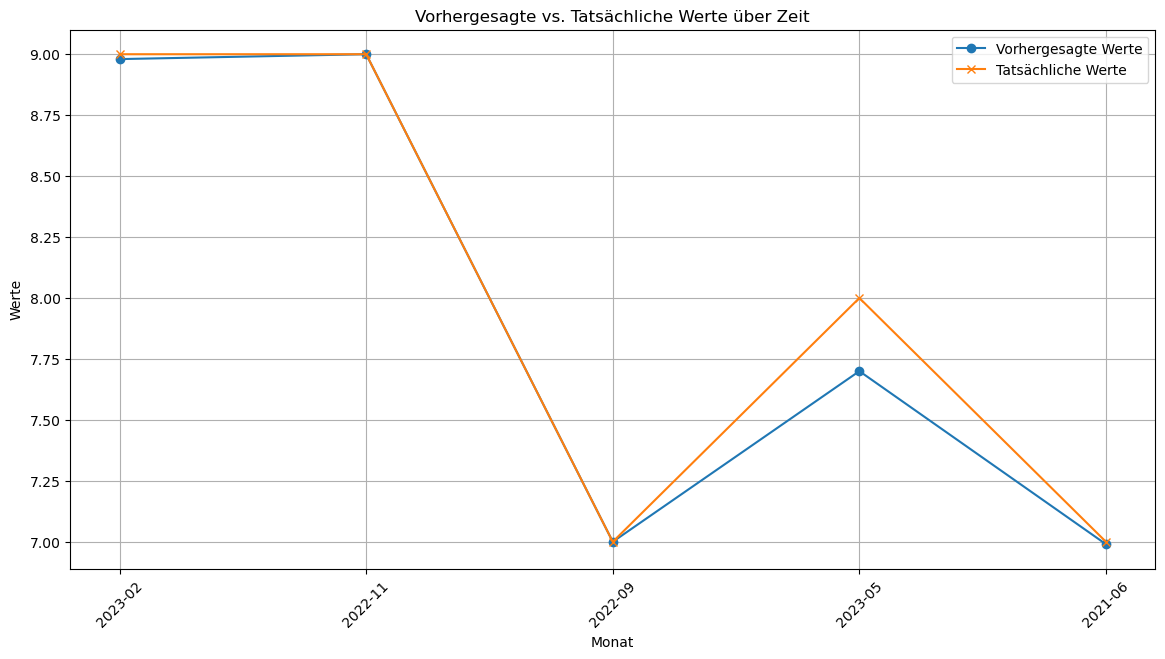

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(porsche_holding["month"], porsche_holding["Vorhergesagte Werte"], label="Vorhergesagte Werte", marker='o')
plt.plot(porsche_holding["month"], porsche_holding["Tatsächliche Werte"], label="Tatsächliche Werte", marker='x')
plt.title("Vorhergesagte vs. Tatsächliche Werte über Zeit")
plt.xlabel("Monat")
plt.ylabel("Werte")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()